<a href="https://colab.research.google.com/github/eimoehtet/shopping-preferences-prediction/blob/main/shopping_preferences_using_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicting Shopping Preferences by Support Vector Machine**

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification and regression tasks. It tries to find the best boundary known as hyperplane that separates different classes in the data.

The main goal of SVM is to maximize the margin between the two classes. The larger the margin the better the model performs on new and unseen data.

## Import the necessary libiraries

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay
import seaborn as sns
import pandas as pd
from sklearn.svm import SVC
from sklearn. inspection import DecisionBoundaryDisplay
from sklearn.preprocessing import LabelBinarizer
from google.colab import drive
import gradio as gr
import warnings
warnings.filterwarnings('ignore')
drive.mount('/content/drive')
from collections import Counter
from imblearn.over_sampling import SMOTE

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **1. Exploratory Data Analysis (EDA)**

### 1.1 Load the DataSet

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Machine Learning/online vs store shopping dataset.csv')
print(f"Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Target distribution:\n{df['shopping_preference'].value_counts()}\n")

Loaded dataset: 11,789 rows × 25 columns
Target distribution:
shopping_preference
Store     10244
Online     1176
Hybrid      369
Name: count, dtype: int64



### 1.2 Data Set Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          11789 non-null  int64  
 1   monthly_income               11789 non-null  int64  
 2   daily_internet_hours         11789 non-null  float64
 3   smartphone_usage_years       11789 non-null  int64  
 4   social_media_hours           11789 non-null  float64
 5   online_payment_trust_score   11789 non-null  int64  
 6   tech_savvy_score             11789 non-null  int64  
 7   monthly_online_orders        11789 non-null  int64  
 8   monthly_store_visits         11789 non-null  int64  
 9   avg_online_spend             11789 non-null  int64  
 10  avg_store_spend              11789 non-null  int64  
 11  discount_sensitivity         11789 non-null  int64  
 12  return_frequency             11789 non-null  int64  
 13  avg_delivery_day

### 1.3 Missing Values

In [4]:
print('Missing values in each column:')
print(df.isnull().sum())


Missing values in each column:
age                            0
monthly_income                 0
daily_internet_hours           0
smartphone_usage_years         0
social_media_hours             0
online_payment_trust_score     0
tech_savvy_score               0
monthly_online_orders          0
monthly_store_visits           0
avg_online_spend               0
avg_store_spend                0
discount_sensitivity           0
return_frequency               0
avg_delivery_days              0
delivery_fee_sensitivity       0
free_return_importance         0
product_availability_online    0
impulse_buying_score           0
need_touch_feel_score          0
brand_loyalty_score            0
environmental_awareness        0
time_pressure_level            0
gender                         0
city_tier                      0
shopping_preference            0
dtype: int64


### 1.4 Descriptive Statistics

In [6]:
# Display descriptive statistics for numerical columns
display(df.describe())

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,return_frequency,avg_delivery_days,delivery_fee_sensitivity,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level
count,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,...,11789.00000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000
mean,48.729409,131704.282382,6.011367,7.597930,2.514471,5.498770,5.534312,24.677581,9.482144,74554.929341,...,4.46747,3.999661,5.468827,5.462041,5.518704,5.486386,5.485368,5.532021,5.448554,5.504114
std,17.899445,68120.726684,1.976811,4.011628,1.263047,2.880366,2.887251,14.431277,5.728825,43167.126595,...,2.88545,1.995881,2.870195,2.882177,2.867613,2.877918,2.877264,2.848796,2.872740,2.876561
min,18.000000,15005.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,523.000000,...,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,33.000000,72450.000000,4.600000,4.000000,1.600000,3.000000,3.000000,12.000000,5.000000,36797.000000,...,2.00000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,49.000000,131916.000000,6.000000,8.000000,2.500000,5.000000,6.000000,25.000000,9.000000,74859.000000,...,4.00000,4.000000,5.000000,5.000000,6.000000,5.000000,5.000000,6.000000,5.000000,6.000000
75%,64.000000,190505.000000,7.400000,11.000000,3.400000,8.000000,8.000000,37.000000,14.000000,112134.000000,...,7.00000,6.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
max,79.000000,249989.000000,12.000000,14.000000,6.000000,10.000000,10.000000,49.000000,19.000000,149996.000000,...,9.00000,7.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


### 1.5 Target Variable Distribution - **Shopping_Preference**

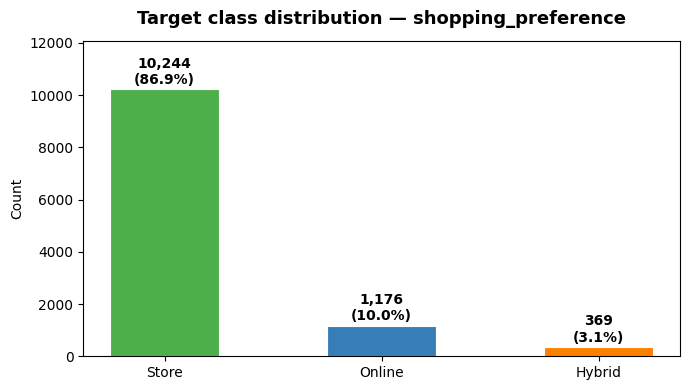

Plot 1 done: target distribution


In [7]:
ORDER = ['Store', 'Online', 'Hybrid']
PALETTE = {'Store': '#4daf4a', 'Online': '#377eb8', 'Hybrid': '#ff7f00'}

# ── Plot 1: Target class distribution ────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
counts = df['shopping_preference'].value_counts().reindex(ORDER)
bars = ax.bar(ORDER, counts.values, color=[PALETTE[x] for x in ORDER], width=0.5,
              edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, counts.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.set_title('Target class distribution — shopping_preference',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout()
plt.show()
print("Plot 1 done: target distribution")

### 1.6 Distribution of Numerical Features

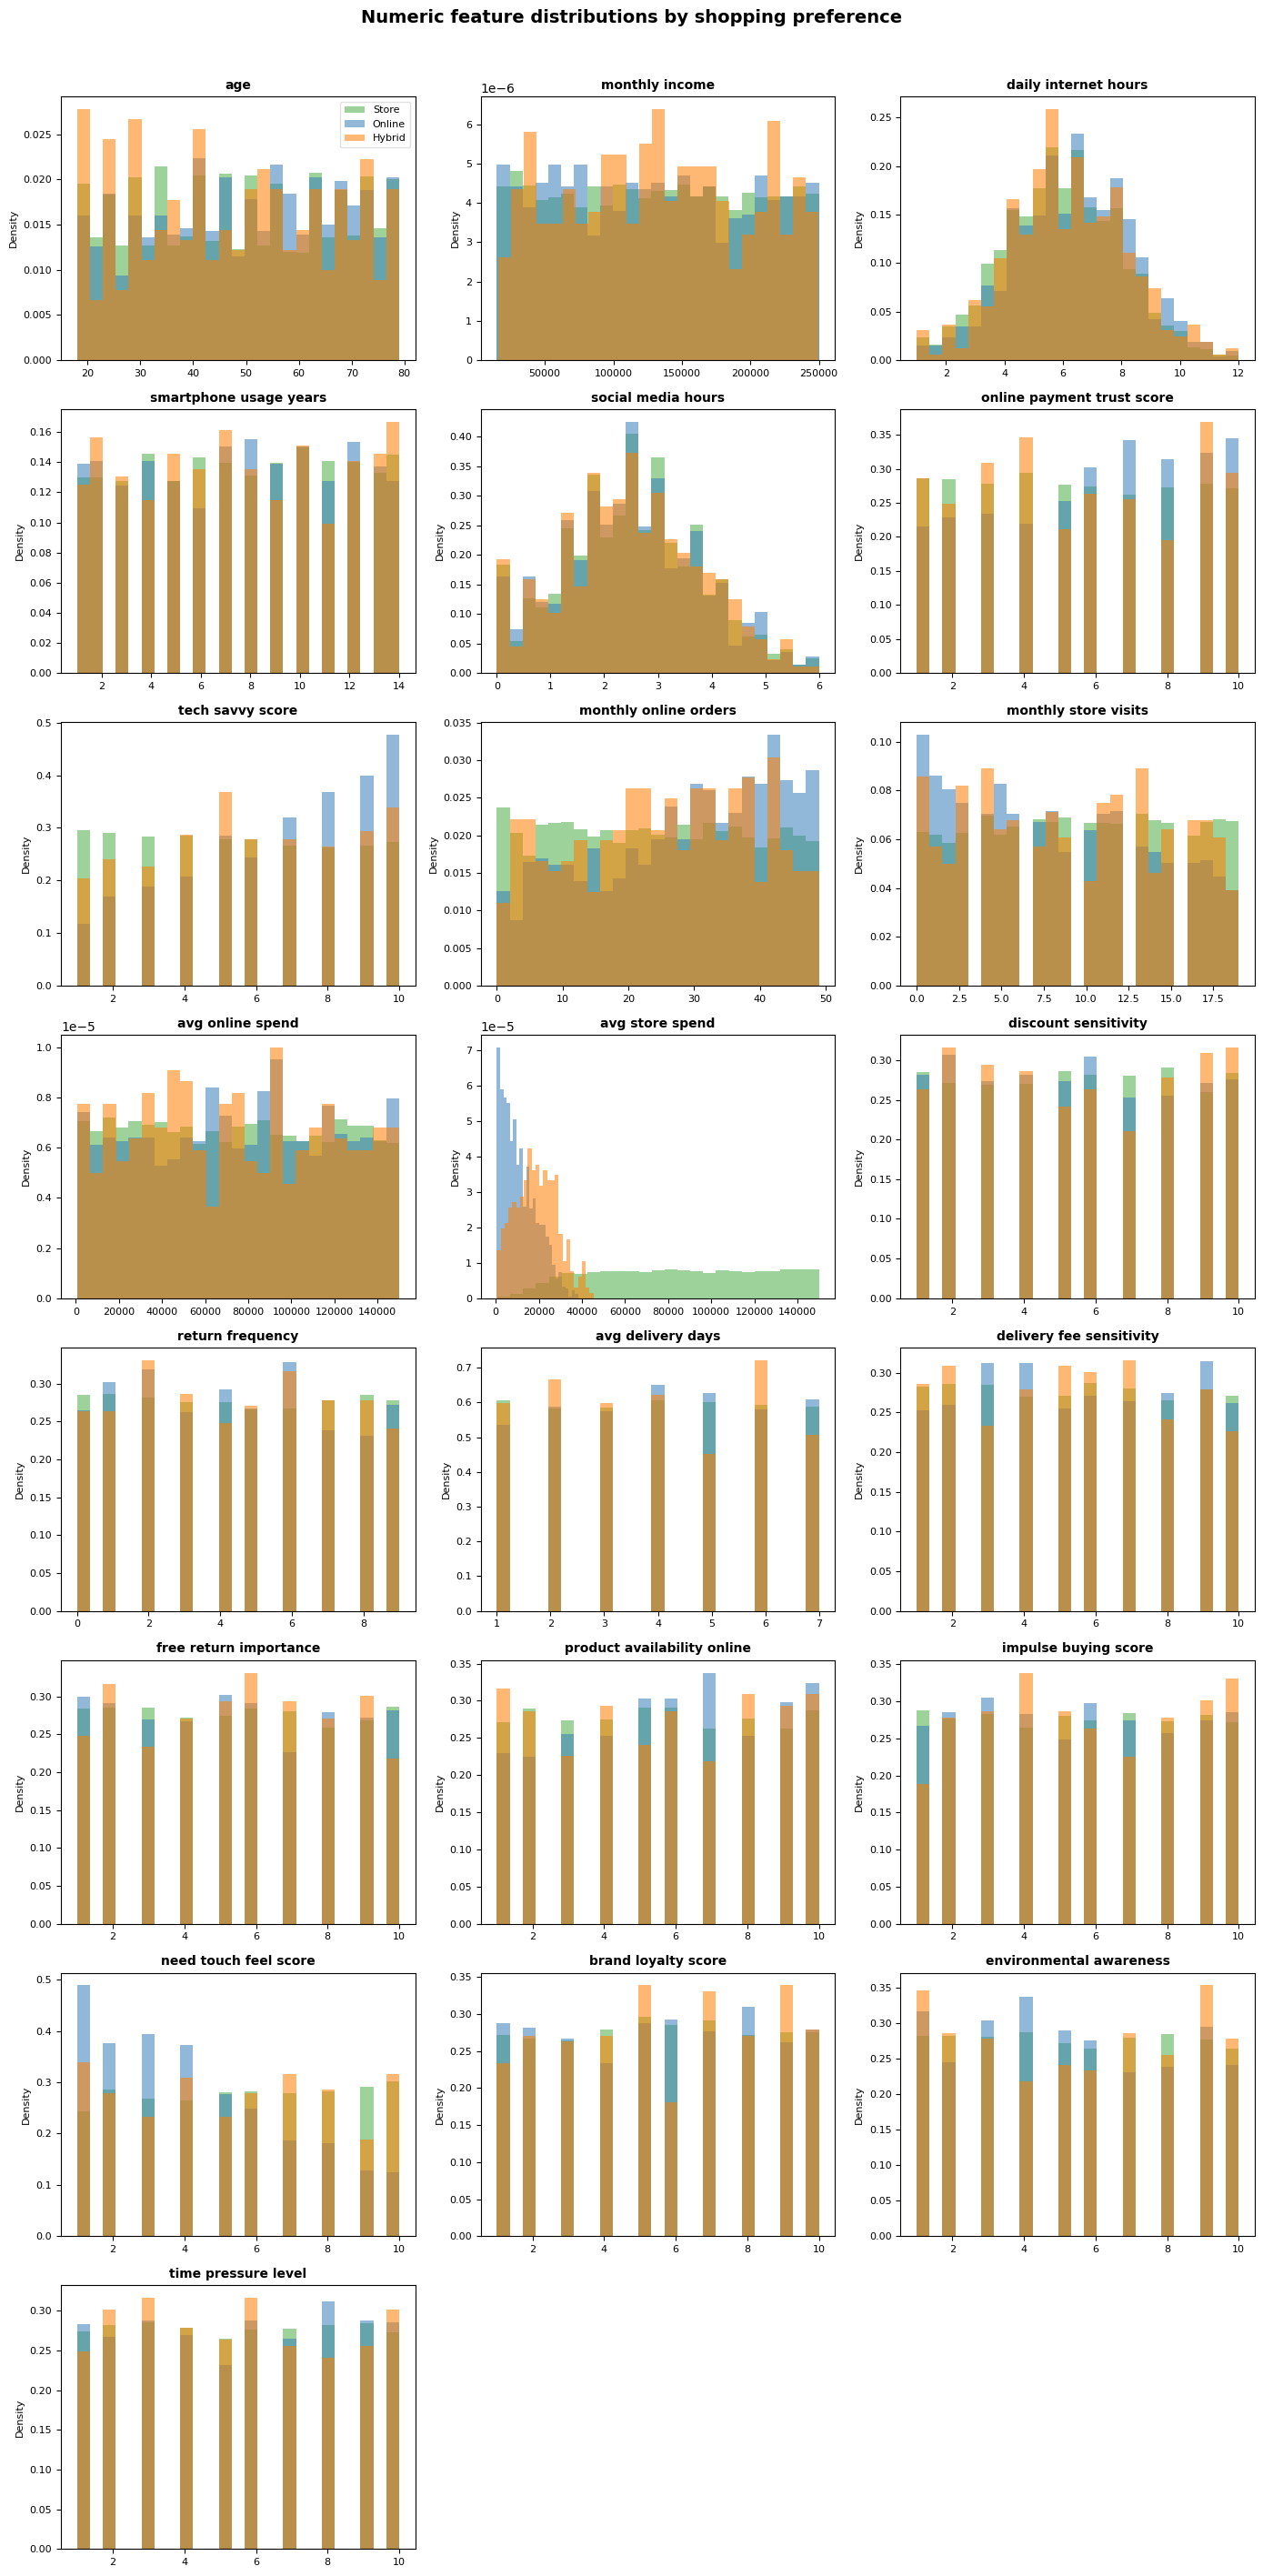

Plot 2 done: numeric histograms


In [8]:
import math
NUMERIC_COLS = df.select_dtypes(include=np.number).columns.tolist()

n_numeric_cols = len(NUMERIC_COLS)
n_cols_per_row = 3
n_rows = math.ceil(n_numeric_cols / n_cols_per_row)

# Adjust figure size dynamically based on the number of rows
fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(14, n_rows * 3.5)) # Adjust height as needed
fig.suptitle('Numeric feature distributions by shopping preference',
             fontsize=14, fontweight='bold', y=1.01)

for i, col in enumerate(NUMERIC_COLS):
    # Ensure we don't try to plot more than available axes if n_numeric_cols is unexpectedly large
    # or if some axes are intentionally left blank.
    if i < n_rows * n_cols_per_row:
        ax = axes.flatten()[i]
        for cls, color in PALETTE.items(): # Changed COLORS to PALETTE
            subset = df[df['shopping_preference'] == cls][col]
            ax.hist(subset, bins=25, alpha=0.55, color=color,
                    label=cls, density=True, edgecolor='none')
        ax.set_title(col.replace('_', ' '), fontsize=10, fontweight='bold')
        ax.set_ylabel('Density', fontsize=8)
        ax.tick_params(labelsize=8)
        if i == 0:
            ax.legend(fontsize=8, framealpha=0.6)
    else:
        # Break the loop if there are more columns than subplots, or handle as needed.
        # This should ideally not be reached with dynamic subplot creation.
        pass

# Turn off any unused subplots
for j in range(i + 1, n_rows * n_cols_per_row):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()
print("Plot 2 done: numeric histograms")

### 1.6 Distribution of Categorical Features

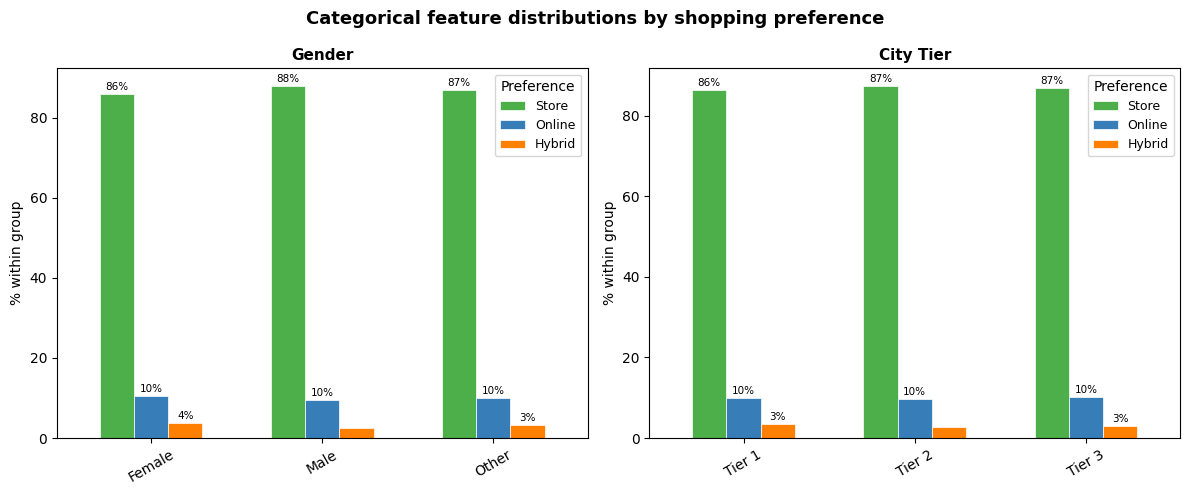

Plot 4 done: categorical features


In [9]:
# ── Plot 4: Categorical features — stacked bar ───────────────
# Shows how gender and city_tier break down within each
# shopping preference group (row-normalised to 100%).
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Categorical feature distributions by shopping preference',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes, ['gender', 'city_tier']):
    ct = (pd.crosstab(df[col], df['shopping_preference'], normalize='index') * 100
          ).reindex(columns=ORDER)
    ct.plot(kind='bar', ax=ax, color=PALETTE, width=0.6,
            edgecolor='white', linewidth=0.5)
    ax.set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_ylabel('% within group')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Preference', fontsize=9)
    for bar in ax.patches:
        h = bar.get_height()
        if h > 3:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
                    f'{h:.0f}%', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.show()
print("Plot 4 done: categorical features")

### 1.7 Correlation heatmap

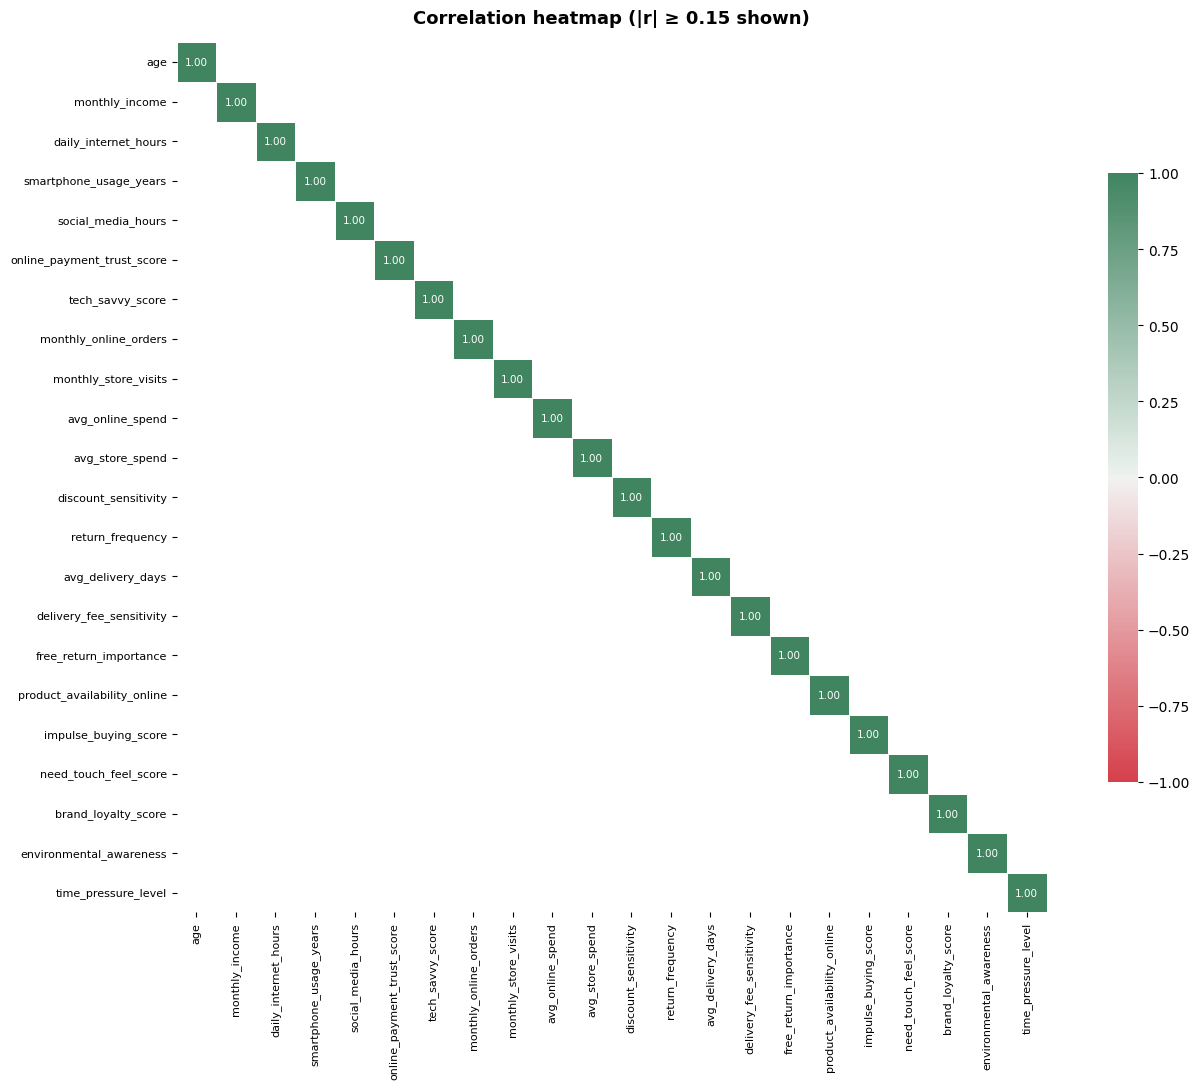

Plot 5 done: correlation heatmap


In [10]:
# Weak correlations (|r| < 0.15) are hidden to reduce noise.
# Pairs with high correlation (>0.7) are candidates for removal
# before training SVM to avoid redundant features.
fig, ax = plt.subplots(figsize=(14, 11))
corr = df.select_dtypes(include='number').corr()
mask = corr.abs() < 0.15   # hide near-zero correlations

cmap = sns.diverging_palette(10, 145, s=70, l=50, as_cmap=True)
sns.heatmap(
    corr, mask=mask, cmap=cmap, center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7.5},
    linewidths=0.4, linecolor='white',
    square=True, ax=ax, cbar_kws={'shrink': 0.7},
)
ax.set_title('Correlation heatmap (|r| ≥ 0.15 shown)',
             fontsize=13, fontweight='bold', pad=14)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()
print("Plot 5 done: correlation heatmap")


The correlation heatmap shows no multicollinearity among features (max |r| = 0.025), so no features were dropped on this basis. Feature importance will instead be evaluated post-training using SVM coefficients or a univariate selector."

## **2. PreProcessing**

2.1 Feature Encoding

We are going to perform feature encoding for the categorical columns 'gender' and city_tier to convert into numerical values.

In [11]:
features = df.drop('shopping_preference', axis=1)
target = df['shopping_preference']

# Perform one-hot encoding on 'features.'
features_encoded = pd.get_dummies(features, ['gender', 'city_tier'], drop_first=True)

print("After feature encoding...")
features_encoded.head(5)


After feature encoding...


,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender_Male,gender_Other,city_tier_Tier 2,city_tier_Tier 3
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,1,3,6,5,2,False,True,False,True
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,4,9,6,8,1,7,True,False,False,True
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,10,1,1,3,3,3,False,False,False,True
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,2,4,8,2,6,6,False,False,False,False
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,5,8,9,7,1,6,True,False,False,True


In [12]:
df.head(5)

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store


## **3. Model Development** - SVM

### Prepare Features (X) and Target (y)

In [13]:
X = features_encoded
y = target

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")
print("Target variable distribution:\n", y.value_counts())

Shape of X: (11789, 26)
Shape of y: (11789,)
Target variable distribution:
 shopping_preference
Store     10244
Online     1176
Hybrid      369
Name: count, dtype: int64


Split Data into Training and Testing Sets

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (9431, 26)
X_test shape: (2358, 26)
y_train shape: (9431,)
y_test shape: (2358,)


Addressing Class Imbalance with SMOTE

In [15]:
# Check the original class distribution in the training data
print("Original training set class distribution:", Counter(y_train))

# Initialize SMOTE (Synthetic Minority Over-sampling Technique)
sm = SMOTE(random_state=42)

# Apply SMOTE to the training data to balance class distribution
X_res, y_res = sm.fit_resample(X_train, y_train)

# Check the new class distribution after SMOTE
print("Resampled training set class distribution:", Counter(y_res))

Original training set class distribution: Counter({'Store': 8182, 'Online': 952, 'Hybrid': 297})
Resampled training set class distribution: Counter({'Store': 8182, 'Online': 8182, 'Hybrid': 8182})


### Feature scaling using Standard Scaler

In [16]:
# SVMs are sensitive to scale! We are going to normalize the data.
scaler = StandardScaler()

# We will fit the scaler on the SMOTEd training data and transform X_res
X_res_scaled = scaler.fit_transform(X_res)

# Transform the test data (X_test) using the SAME scaler
X_test_scaled = scaler.transform(X_test)

### Training data

In [17]:
# Initialize the SVM Classifier with a 'rbf' kernel
model = SVC(kernel='rbf')

# Fit the model to the SCALED, RESAMPLED training data
model.fit(X_res_scaled, y_res)

# Use the model to predict labels for the SCALED test data
predictions = model.predict(X_test_scaled)


# --- Evaluation ---
if predictions is not None:
    print(classification_report(y_test, predictions))
else:
    print("Error.")

plt.show()

              precision    recall  f1-score   support

      Hybrid       0.28      0.29      0.28        72
      Online       0.89      0.91      0.90       224
       Store       0.98      0.98      0.98      2062

    accuracy                           0.95      2358
   macro avg       0.72      0.73      0.72      2358
weighted avg       0.95      0.95      0.95      2358



### Hyperparameter Tuning by GridSearchCV

In [18]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for GridSearchCV
# For SVC with an 'rbf' kernel, common parameters to tune are C and gamma.
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'gamma': [1, 0.1, 0.01, 0.001], # Kernel coefficient
    'kernel': ['rbf'] # Specify kernel
}

# Initialize a new SVC model (GridSearchCV will create new instances during tuning)
svc = SVC(random_state=42)

# Initialize GridSearchCV
# cv=5 for 5-fold cross-validation
# scoring='f1_weighted' is often good for imbalanced datasets like this one
# verbose=3 provides more output during the search process
grid_search = GridSearchCV(svc, param_grid, cv=5, scoring='f1_weighted', verbose=2, n_jobs=-1)

# Fit GridSearchCV to the SCALED, RESAMPLED training data
print("Starting GridSearchCV...")
grid_search.fit(X_res_scaled, y_res)
print("GridSearchCV completed.")

# Print the best parameters and best score
print("\nBest parameters found:", grid_search.best_params_)
print("Best cross-validation F1-weighted score:", grid_search.best_score_)

# Get the best model
best_svm_model = grid_search.best_estimator_

# Evaluate the best model on the test data
predictions_tuned = best_svm_model.predict(X_test_scaled)

# Print classification report for the tuned model
print("\nClassification report for the best tuned SVM model:")
print(classification_report(y_test, predictions_tuned))

Starting GridSearchCV...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
GridSearchCV completed.

Best parameters found: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Best cross-validation F1-weighted score: 0.9953994465857899

Classification report for the best tuned SVM model:
              precision    recall  f1-score   support

      Hybrid       0.53      0.56      0.54        72
      Online       0.95      0.95      0.95       224
       Store       0.99      0.99      0.99      2062

    accuracy                           0.97      2358
   macro avg       0.82      0.83      0.83      2358
weighted avg       0.97      0.97      0.97      2358



### Confusion Matrix


--- Performance Metrics for Best Tuned SVM Model ---

              precision    recall  f1-score   support

      Hybrid       0.53      0.56      0.54        72
      Online       0.95      0.95      0.95       224
       Store       0.99      0.99      0.99      2062

    accuracy                           0.97      2358
   macro avg       0.82      0.83      0.83      2358
weighted avg       0.97      0.97      0.97      2358


--- Visualizing Model Performance ---



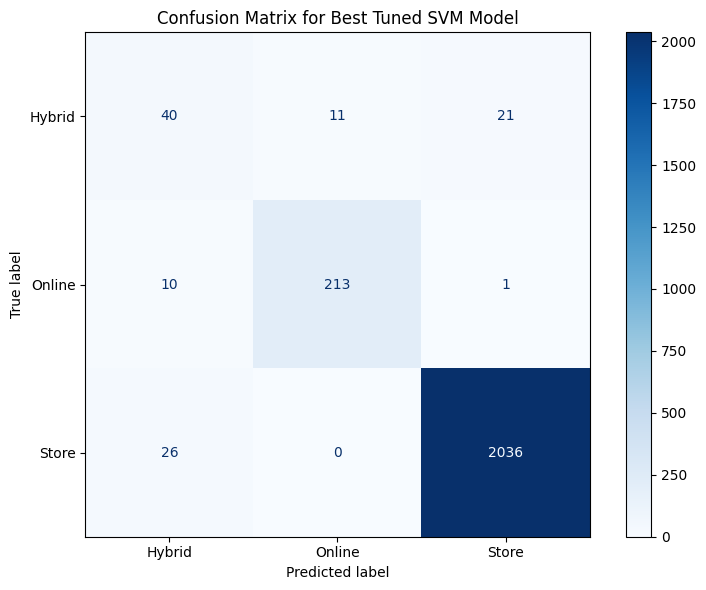

Confusion Matrix displayed.


In [22]:
# --- Performance Metrics and Visualization ---

print("\n--- Performance Metrics for Best Tuned SVM Model ---\n")
# Display Classification Report again for easy reference
print(classification_report(y_test, predictions_tuned))

print("\n--- Visualizing Model Performance ---\n")

# 1. Confusion Matrix
cm = confusion_matrix(y_test, predictions_tuned, labels=best_svm_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_svm_model.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title('Confusion Matrix for Best Tuned SVM Model')
plt.tight_layout()
plt.show()

print("Confusion Matrix displayed.")

### ROC Curve (One-vs-Rest)

For multi-class classification, we can visualize the ROC curve using a 'One-vs-Rest' (OvR) approach. This means we compare each class against all other classes combined.

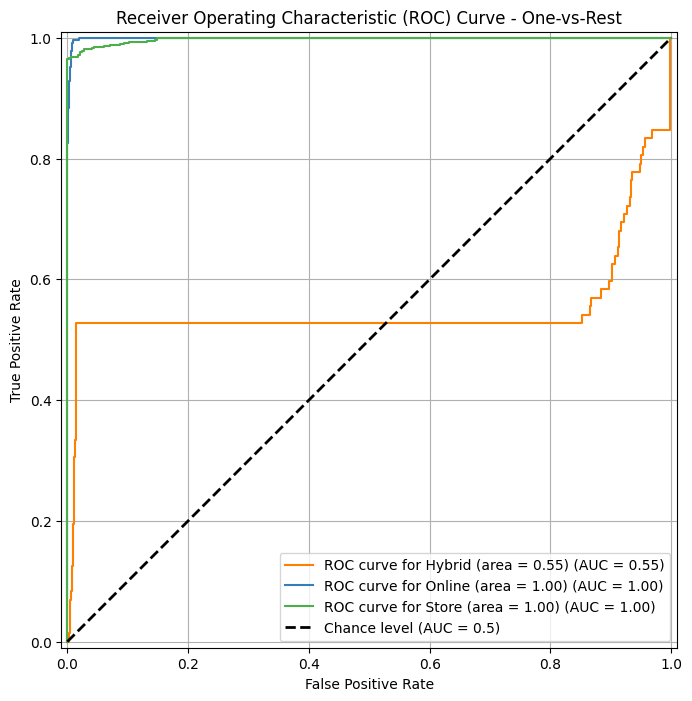

In [32]:
# Binarize the output for one-vs-rest ROC curve
label_binarizer = LabelBinarizer().fit(y_train)
y_test_binarized = label_binarizer.transform(y_test)

# Get decision function scores for each class
# SVC decision_function is used as probability=True was not set in SVC during training,
# which is generally more reliable for ROC than predicted probabilities if available.
# It outputs a score per class, higher score means higher confidence for that class.
if hasattr(best_svm_model, 'decision_function'):
    y_score = best_svm_model.decision_function(X_test_scaled)
elif hasattr(best_svm_model, 'predict_proba'):
    y_score = best_svm_model.predict_proba(X_test_scaled)
else:
    print("Model does not have decision_function or predict_proba.")
    y_score = None

if y_score is not None:
    fig, ax = plt.subplots(figsize=(10, 8))
    for i, class_label in enumerate(label_binarizer.classes_):
        # Get ROC curve for current class
        fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)

        # Plot ROC curve using the constructor and plot method (compatible with older scikit-learn versions)
        RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot(
            ax=ax,
            name=f'ROC curve for {class_label} (area = {roc_auc:.2f})',
            color=PALETTE[class_label] # Use predefined PALETTE with class_label as key
        )

    ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance level (AUC = 0.5)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('Receiver Operating Characteristic (ROC) Curve - One-vs-Rest')
    ax.legend(loc="lower right")
    plt.grid(True)
    plt.show()
else:
    print("Cannot plot ROC curve: Decision function or probabilities not available.")

### Error Distributions Analysis



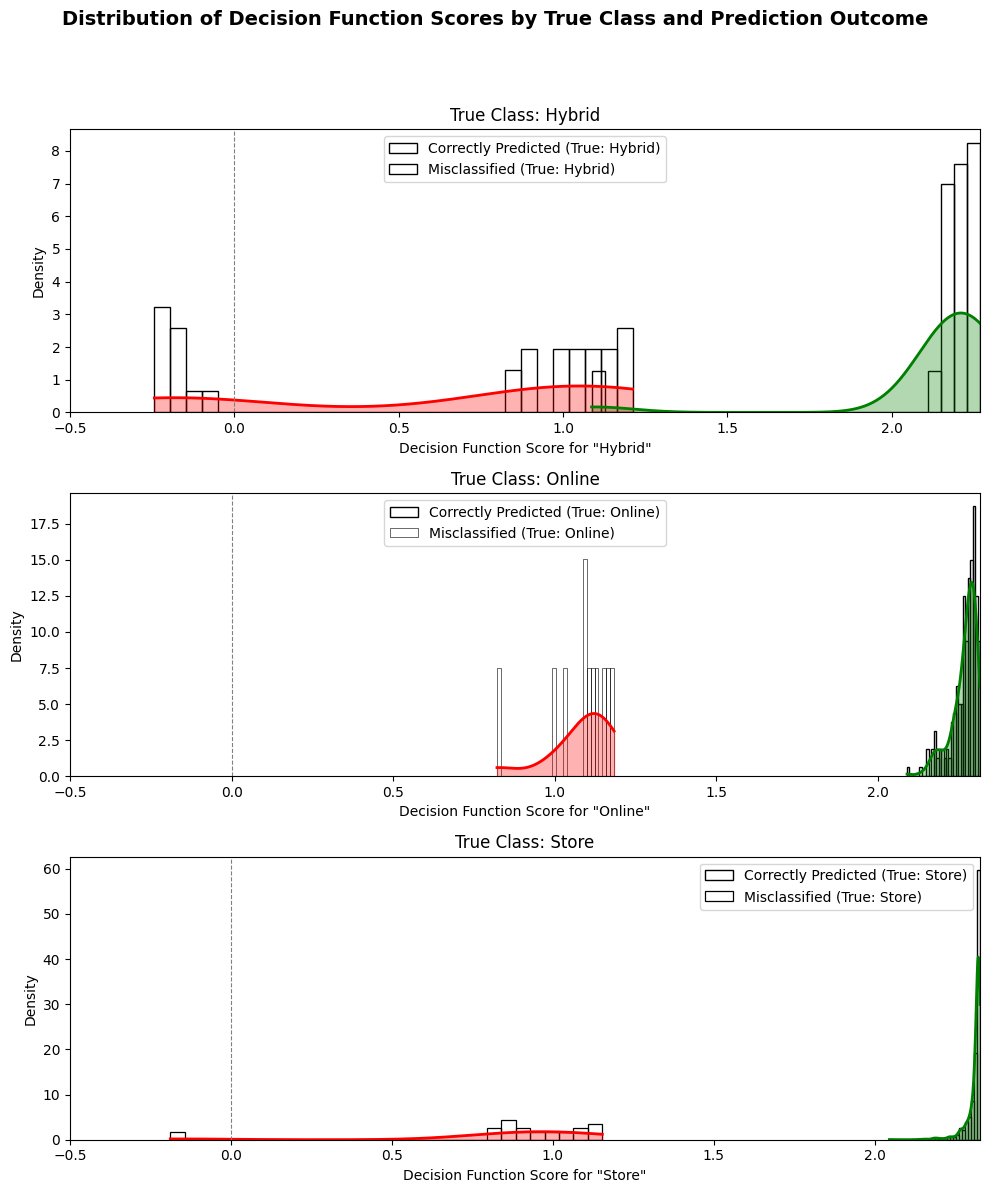

In [33]:
# Ensure y_score is available from the ROC curve generation step
# It should contain the decision function values from the best_svm_model

if 'y_score' in locals() and y_score is not None:
    # Get the class labels in the order they appear in y_score columns
    # This assumes best_svm_model.classes_ provides the correct order
    classes = best_svm_model.classes_

    fig, axes = plt.subplots(len(classes), 1, figsize=(10, 4 * len(classes)))
    if len(classes) == 1:
        axes = [axes] # Ensure axes is iterable even for a single class

    fig.suptitle('Distribution of Decision Function Scores by True Class and Prediction Outcome',
                 fontsize=14, fontweight='bold', y=1.02)

    for i, class_label in enumerate(classes):
        ax = axes[i]

        # Filter data for the current true class
        true_class_indices = (y_test == class_label)
        # Scores for the true class itself for samples belonging to that true class
        true_class_scores = y_score[true_class_indices, i]
        true_class_predictions = predictions_tuned[true_class_indices]

        # Separate into correctly and incorrectly predicted samples for this true class
        correctly_predicted_mask = (true_class_predictions == class_label)
        incorrectly_predicted_mask = (true_class_predictions != class_label)

        # Plot distributions for correctly and incorrectly predicted samples
        sns.histplot(true_class_scores[correctly_predicted_mask], color='green', kde=True,
                     label=f'Correctly Predicted (True: {class_label})', ax=ax, stat='density', alpha=0.0,
                     line_kws={'linewidth': 2}, bins=30) # Draw KDE only for correctly classified
        sns.histplot(true_class_scores[incorrectly_predicted_mask], color='red', kde=True,
                     label=f'Misclassified (True: {class_label})', ax=ax, stat='density', alpha=0.0,
                     line_kws={'linewidth': 2}, bins=30) # Draw KDE only for misclassified

        # Fill the areas for better visual distinction
        # Access the KDE line data directly from ax.lines
        ax.fill_between(ax.lines[0].get_xdata(),
                        ax.lines[0].get_ydata(), color='green', alpha=0.3)
        ax.fill_between(ax.lines[1].get_xdata(),
                        ax.lines[1].get_ydata(), color='red', alpha=0.3)

        ax.set_title(f'True Class: {class_label}', fontsize=12)
        ax.set_xlabel(f'Decision Function Score for "{class_label}"')
        ax.set_ylabel('Density')
        ax.legend()

        # Add a vertical line at the decision boundary (score = 0)
        ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, label='Decision Boundary (0)')

        # Adjust x-axis limits to ensure the decision boundary is always visible
        min_score = min(true_class_scores)
        max_score = max(true_class_scores)
        ax.set_xlim(min(min_score, -0.5), max(max_score, 0.5))

    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
    plt.show()
else:
    print("Cannot plot error distributions: Decision function scores (y_score) not available.")

### Create Gradio Interface

Now, let's create a Gradio interface. We need a function that takes the raw inputs, processes them (one-hot encoding and scaling), and then uses the trained SVM model to make a prediction.

In [25]:
pip install --upgrade gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.0 MB/s eta 0:00:00
  Attempting uninstall: gradio-client
    Found existing installation: gradio_client 1.14.0
    Uninstalling gradio_client-1.14.0:
      Successfully uninstalled gradio_client-1.14.0
  Attempting uninstall: gradio
    Found existing installation: gradio 5.50.0
    Uninstalling gradio-5.50.0:
      Successfully uninstalled gradio-5.50.0


In [34]:
def predict_shopping_preference(
    age, monthly_income, daily_internet_hours, smartphone_usage_years,
    social_media_hours, online_payment_trust_score, tech_savvy_score,
    monthly_online_orders, monthly_store_visits, avg_online_spend,
    avg_store_spend, discount_sensitivity, return_frequency, avg_delivery_days,
    delivery_fee_sensitivity, free_return_importance, product_availability_online,
    impulse_buying_score, need_touch_feel_score, brand_loyalty_score,
    environmental_awareness, time_pressure_level, gender, city_tier
):
    try:
        # Create a single-row DataFrame with the *original* column names and types
        # This includes the categorical columns in their original string format
        input_df_original = pd.DataFrame([{
            'age': age,
            'monthly_income': monthly_income,
            'daily_internet_hours': daily_internet_hours,
            'smartphone_usage_years': smartphone_usage_years,
            'social_media_hours': social_media_hours,
            'online_payment_trust_score': online_payment_trust_score,
            'tech_savvy_score': tech_savvy_score,
            'monthly_online_orders': monthly_online_orders,
            'monthly_store_visits': monthly_store_visits,
            'avg_online_spend': avg_online_spend,
            'avg_store_spend': avg_store_spend,
            'discount_sensitivity': discount_sensitivity,
            'return_frequency': return_frequency,
            'avg_delivery_days': avg_delivery_days,
            'delivery_fee_sensitivity': delivery_fee_sensitivity,
            'free_return_importance': free_return_importance,
            'product_availability_online': product_availability_online,
            'impulse_buying_score': impulse_buying_score,
            'need_touch_feel_score': need_touch_feel_score,
            'brand_loyalty_score': brand_loyalty_score,
            'environmental_awareness': environmental_awareness,
            'time_pressure_level': time_pressure_level,
            'gender': gender,         # Original categorical
            'city_tier': city_tier   # Original categorical
        }])

        print("Original input DataFrame shape:", input_df_original.shape)
        print("Original input DataFrame columns:", input_df_original.columns.tolist())

        # Apply one-hot encoding using pd.get_dummies, similar to how training data was processed
        # Ensure 'features_encoded.columns' is accessible and correctly reflects dummy columns
        input_data_encoded = pd.get_dummies(input_df_original, columns=['gender', 'city_tier'], drop_first=True)

        print("Encoded input DataFrame shape:", input_data_encoded.shape)
        print("Encoded input DataFrame columns:", input_data_encoded.columns.tolist())

        # Ensure all columns from the training data (features_encoded) are present, filling missing with False (0)
        # and also ensure the order is correct.
        # It's crucial that features_encoded.columns is derived from the *full* training set.
        input_data_aligned = input_data_encoded.reindex(columns=features_encoded.columns, fill_value=False)

        # Explicitly convert boolean columns to numeric (0/1) if they exist after reindex
        for col in ['gender_Male', 'gender_Other', 'city_tier_Tier 2', 'city_tier_Tier 3']:
            if col in input_data_aligned.columns and input_data_aligned[col].dtype == 'bool':
                input_data_aligned[col] = input_data_aligned[col].astype(int)

        print("Aligned input DataFrame shape:", input_data_aligned.shape)
        print("Aligned input DataFrame columns:", input_data_aligned.columns.tolist())

        # Scale the input data
        # Ensure scaler is fitted and available globally
        input_data_scaled = scaler.transform(input_data_aligned)

        print("Scaled input data shape:", input_data_scaled.shape)

        # Make prediction
        prediction = model.predict(input_data_scaled)[0]
        return prediction
    except Exception as e:
        print(f"Error in predict_shopping_preference: {e}")
        import traceback
        traceback.print_exc() # Print full traceback
        return "Prediction Error" # Return a user-friendly error message to Gradio

In [30]:
inputs = [
    gr.Slider(minimum=18, maximum=90, value=30, label="Age"),
    gr.Slider(minimum=0, maximum=300000, value=50000, label="Monthly Income"),
    gr.Slider(minimum=0, maximum=24, value=5.0, label="Daily Internet Hours"),
    gr.Slider(minimum=0, maximum=20, value=5, label="Smartphone Usage Years"),
    gr.Slider(minimum=0, maximum=10, value=2.0, label="Social Media Hours"),
    gr.Slider(minimum=1, maximum=10, value=5, label="Online Payment Trust Score"),
    gr.Slider(minimum=1, maximum=10, value=5, label="Tech Savvy Score"),
    gr.Slider(minimum=0, maximum=30, value=5, label="Monthly Online Orders"),
    gr.Slider(minimum=0, maximum=20, value=2, label="Monthly Store Visits"),
    gr.Slider(minimum=0, maximum=200000, value=1000, label="Avg Online Spend"),
    gr.Slider(minimum=0, maximum=100000, value=500, label="Avg Store Spend"),
    gr.Slider(minimum=1, maximum=10, value=5, label="Discount Sensitivity"),
    gr.Slider(minimum=0, maximum=10, value=1, label="Return Frequency"),
    gr.Slider(minimum=1, maximum=30, value=5, label="Avg Delivery Days"),
    gr.Slider(minimum=1, maximum=10, value=5, label="Delivery Fee Sensitivity"),
    gr.Slider(minimum=1, maximum=10, value=5, label="Free Return Importance"),
    gr.Slider(minimum=1, maximum=10, value=5, label="Product Availability Online"),
    gr.Slider(minimum=1, maximum=10, value=5, label="Impulse Buying Score"),
    gr.Slider(minimum=1, maximum=10, value=5, label="Need Touch Feel Score"),
    gr.Slider(minimum=1, maximum=10, value=5, label="Brand Loyalty Score"),
    gr.Slider(minimum=1, maximum=10, value=5, label="Environmental Awareness"),
    gr.Slider(minimum=1, maximum=10, value=5, label="Time Pressure Level"),
    gr.Radio(['Female', 'Male', 'Other'], label="Gender", value='Female'),
    gr.Radio(['Tier 1', 'Tier 2', 'Tier 3'], label="City Tier", value='Tier 1')
]

# Define Gradio output
output = gr.Label()

# Create the Gradio interface
interface = gr.Interface(
    fn=predict_shopping_preference,
    inputs=inputs,
    outputs=output,
    title="Shopping Preferenc e Predictor (SVM)",
    description="Enter customer details to predict their shopping preference (Store, Online, or Hybrid)."
)

# Launch the interface
interface.launch(inline=True, share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://31ceafe568f727f16a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Original input DataFrame shape: (1, 24)
Original input DataFrame columns: ['age', 'monthly_income', 'daily_internet_hours', 'smartphone_usage_years', 'social_media_hours', 'online_payment_trust_score', 'tech_savvy_score', 'monthly_online_orders', 'monthly_store_visits', 'avg_online_spend', 'avg_store_spend', 'discount_sensitivity', 'return_frequency', 'avg_delivery_days', 'delivery_fee_sensitivity', 'free_return_importance', 'product_availability_online', 'impulse_buying_score', 'need_touch_feel_score', 'brand_loyalty_score', 'environmental_awareness', 'time_pressure_level', 'gender', 'city_tier']
Encoded input DataFrame shape: (1, 22)
Encoded input DataFrame columns: ['age', 'monthly_income', 'daily_internet_hours', 'smartphone_usage_years', 'social_media_hours', 'online_payment_trust_score', 'tech_savvy_score', 'monthly_online_orders', 'monthly_store_visits', 'avg_online_spend', 'avg_store_spend', 'discount_sensitivity', 'return_frequency', 'avg_delivery_days', 'delivery_fee_sensitiv